## Load libraries

In [1]:
import numpy as np
import os
from aicsimageio import AICSImage
from aicsimageio.writers import OmeTiffWriter
import pandas as pd
from skimage.measure import regionprops_table
from aicsimageio.types import PhysicalPixelSizes
import matplotlib.pyplot as plt
from tqdm import tqdm


c:\Users\s03434mv\AppData\Local\anaconda3\envs\dashUND_track\lib\site-packages\pydantic\_migration.py:275: UserWarning: `pydantic.error_wrappers:ValidationError` has been moved to `pydantic:ValidationError`.
  warnings.warn(f'`{import_path}` has been moved to `{new_location}`.')


In [2]:
# List of region properties to extract for the output table. See skimage.measure.regionprops_table 
# documentation for details on each property.
# Commented-out/uncomment properties to include/exclude them from the output table. 
# Note that some properties require an intensity image to be provided when calling regionprops_table(...).
REGIONPROPS_FOR_TABLE = (
    # always ok (no intensity image needed)
    "label",
    "area",
    #"bbox",
    #"bbox_area",
    "centroid",
    "convex_area",
    "eccentricity",
    #"equivalent_diameter_area",
    #"euler_number",
    #"extent",
    #"feret_diameter_max",
    #"filled_area",
    #"inertia_tensor",
    #"inertia_tensor_eigvals",
    #"local_centroid",
    "major_axis_length",
    "minor_axis_length",
    #"moments",
    #"moments_central",
    #"moments_hu",
    #"moments_normalized",
    "orientation",
    "perimeter",
    #"perimeter_crofton",
    "solidity",

    # require intensity_image=... when calling regionprops_table(...)
    "max_intensity",
    "mean_intensity",
    "min_intensity",
    #"weighted_centroid",
    #"weighted_local_centroid",
    #"moments_weighted",
    #"moments_weighted_central",
    #"moments_weighted_hu",
    #"moments_weighted_normalized",
)


## Setting up paths

Modify this cell to set paths to your input (**ROOT_DIR**) and output (**SAVE_DIR**) root directories.  
Input directory structure must be:

```text
ROOT_DIR/
├─ CELL_LINE_1/
│  ├─ TECH_REP_1/
│  │  ├─ Nucleus/
│  │  │  └─ mask.npy        # nuclear masks (segmentation output)
│  │  ├─ Cytoplasm/
│  │  │  └─ mask.npy        # cytoplasmic masks (segmentation output)
│  │  └─ Raw Data/
│  │     └─ *.nd2           # single-position raw image files
│  ├─ TECH_REP_2/
│  │  └─ ...
│
├─ CELL_LINE_2/
│  └─ ...
```

The same structure applies to **SAVE_DIR**, where results will be saved.  
The **SAVE_DIR** folder and its internal structure will be created if it does not exist.


In [3]:
# Modifiable parameters - CHANGE AS NEEDED
ROOT_DIR = r"\\HIVE2006\projects\Miruna_Verdes\Users temp\Jakub\new_to_process\Segmentation Data" # Change to your ROOT_DIR. Format should be r"path_to_your_directory"
SAVE_DIR = r"\\HIVE2006\projects\Miruna_Verdes\Users temp\Jakub\new_to_process\Results" # Change to your SAVE_DIR. Format should be r"path_to_your_directory"


In [4]:
# Do not change the lines below
from datetime import datetime
today = datetime.now().strftime("%d-%m-%Y")
SAVE_DIR += f"\\Nuclear_vs_Cytoplasmic_analysis_{today}"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Results will be saved to: {SAVE_DIR}")

Results will be saved to: \\HIVE2006\projects\Miruna_Verdes\Users temp\Jakub\new_to_process\Results\Nuclear_vs_Cytoplasmic_analysis_01-04-2026


## Helper funcitons

Leave this section as it is

In [5]:

def get_mask_path_pairs(nuclear_mask_dir, cytoplasmic_mask_dir):
    """
    Get pairs of nuclear and cytoplasmic mask file paths based on matching filenames.
    
    Parameters:
    nuclear_mask_dir (str): Directory containing nuclear mask files.
    cytoplasmic_mask_dir (str): Directory containing cytoplasmic mask files.
    
    Returns:
    list of tuples: A list of tuples where each tuple contains the file paths for a nuclear mask and its corresponding cytoplasmic mask.
    """
    nuclear_files = sorted([f for f in os.listdir(nuclear_mask_dir) if f.endswith('.npy')])
    cytoplasmic_files = sorted([f for f in os.listdir(cytoplasmic_mask_dir) if f.endswith('.npy')])
    
    mask_path_pairs = []
    for nuc_file in nuclear_files:
        base_name = os.path.splitext(nuc_file)[0]
        cyto_file = base_name + '.npy'
        if cyto_file in cytoplasmic_files:
            nuc_path = os.path.join(nuclear_mask_dir, nuc_file)
            cyto_path = os.path.join(cytoplasmic_mask_dir, cyto_file)
            mask_path_pairs.append((nuc_path, cyto_path))
    
    return mask_path_pairs

def get_masks(nuclear_mask_path=None, cytoplasmic_mask_path=None):
    """
    Load nuclear and cytoplasmic masks from file paths.
    
    Returns:
    tuple: A tuple containing two numpy arrays - (nuclear_mask, cytoplasmic_mask).
    """

    nuclear_mask = np.load(nuclear_mask_path).squeeze()
    cytoplasmic_mask = np.load(cytoplasmic_mask_path).squeeze()
    
    return nuclear_mask, cytoplasmic_mask

def relabel_nuclei(nuclear_mask, cell_mask, overlap_threshold=0.5):
    """
    Relabel nuclei in the nuclear mask to match the cytoplasm it overlaps with more than the overlap threshold.
    At the same time, remove:
    - nuclei that do not overlap with any cytoplasm
    - cells where multiple nuclei overlap with the same cytoplasm
    - cells that do not have any overlapping nuclei
    - cells with one overlapping nucleus that is larger than the cell itself.
    
    Parameters:
    nuclear_mask (np.ndarray): The nuclear mask array.
    cell_mask (np.ndarray): The full cell mask array.
    overlap_threshold (float): The minimum overlap ratio required to assign a nucleus to a cytoplasm.
    
    Returns:
    list[np.ndarray]: The relabeled nuclear mask, cell masks with multi-nuclei masks excluded, 
                        and cytoplasmic mask (cells with nuclei excluded).
    """
    relabeled_nuclear_mask = np.zeros_like(nuclear_mask)
    unique_cells = np.unique(cell_mask)
    unique_cells = unique_cells[unique_cells != 0]  # Exclude background

    for cell in unique_cells:
        #debug 
        if cell==135:
            pass
        cell_region = (cell_mask == cell)
        unique_nuclei = np.unique(nuclear_mask[cell_region])
        overlapping_nuclei = unique_nuclei[unique_nuclei != 0]  # Exclude background
        
        if len(overlapping_nuclei) == 0: # No overlapping nuclei
            cell_mask[cell_region] = 0  # Remove cell with no overlapping nuclei
            continue  
    
        assigned_nucleus = None
        for nucleus in overlapping_nuclei:
            nucleus_region = (nuclear_mask == nucleus)
            intersection = np.logical_and(cell_region, nucleus_region).sum()
            nucleus_area = nucleus_region.sum()
            overlap_ratio = intersection / nucleus_area
            
            if overlap_ratio > overlap_threshold:
                if assigned_nucleus is not None:
                    assigned_nucleus = -1  # Multiple nuclei overlap, invalidate
                    break # Stop checking further, this cell is invalid and the rest of the overlapping nuclei
                        # will be ignored
                elif nucleus_area > cell_region.sum():
                    assigned_nucleus = -1  # Nucleus larger than cell, invalidate
                    break
                assigned_nucleus = nucleus
        
        if assigned_nucleus is not None and assigned_nucleus != -1:
            relabeled_nuclear_mask[nuclear_mask == assigned_nucleus] = cell

        elif assigned_nucleus == -1:
            cell_mask[cell_region] = 0  # Remove cell with multiple overlapping nuclei
        elif assigned_nucleus is None:
            cell_mask[cell_region] = 0  # Remove cell with no valid overlapping nuclei

    return relabeled_nuclear_mask, cell_mask

def get_cytoplasm_mask(nuclear_mask, cytoplasmic_mask):
    """
    Generate a cytoplasmic mask by excluding nuclear regions from the cytoplasmic mask.
    
    Parameters:
    nuclear_mask (np.ndarray): The nuclear mask array.
    cytoplasmic_mask (np.ndarray): The cytoplasmic mask array.
    
    Returns:
    np.ndarray: The cytoplasmic mask with nuclei excluded.
    """
    cytoplasm_only_mask = np.copy(cytoplasmic_mask)
    cytoplasm_only_mask[nuclear_mask > 0] = 0  # Set nuclear regions to background
    return cytoplasm_only_mask  

def get_membrane_mask(cytoplasmic_mask):
    """
    Generate a membrane mask by identifying the borders of the cytoplasmic mask.
    
    Parameters:
    cytoplasmic_mask (np.ndarray): The cytoplasmic mask array.
    
    Returns:
    np.ndarray: The membrane mask.
    """
    from skimage.segmentation import find_boundaries
    membrane_mask = find_boundaries(cytoplasmic_mask, mode='inner').astype(np.uint16)
    membrane_mask *= cytoplasmic_mask  # Retain original labels
    return membrane_mask


def total_intensity(intensity_image, mask):
    """
    Calculate the total intensity within the masked regions of the intensity image.
    Compatible with regionprops_table to be used as a custom property function.
    
    Parameters:
    intensity_image (np.ndarray): The intensity image array.
    mask (np.ndarray): The mask array.
    
    Returns:
    float: The total intensity within the masked regions.
    """
    total_intensity = np.sum(intensity_image*mask)
    return total_intensity   




In [6]:
def get_membrane_mask_variable_thickness(cytoplasmic_mask, thickness=3):
    """
    Generate a membrane mask (inner boundary of cytoplasm) with variable thickness.
    """
    from skimage.segmentation import find_boundaries
    from scipy.ndimage import distance_transform_edt

    cytoplasmic_mask = cytoplasmic_mask.astype(np.uint16)
    # Inner boundary of each labeled region
    inner_boundary = find_boundaries(cytoplasmic_mask, mode='inner')
    # Distance to inner boundary, computed on the label mask
    dist = distance_transform_edt(~inner_boundary)
    membrane_mask = np.where((cytoplasmic_mask > 0) & (dist <= thickness), cytoplasmic_mask, 0).astype(np.uint16)
    return membrane_mask

In [7]:
def get_regionprops_with_ratio(nuclear_mask, cytoplasmic_mask, membrane_mask, intensity_image, n_channels=1):
    """
    Calculate region properties for nuclei, cytoplasm, and membrane including intensity ratios.
    """
    # Squeeze arrays to remove single-dimensional entries
    nuclear_mask = np.squeeze(nuclear_mask)
    cytoplasmic_mask = np.squeeze(cytoplasmic_mask)
    membrane_mask = np.squeeze(membrane_mask)
    intensity_image = np.squeeze(intensity_image)

    nuclear_props = regionprops_table(nuclear_mask, intensity_image=intensity_image,
                                      properties=REGIONPROPS_FOR_TABLE, extra_properties=[total_intensity])
    cytoplasmic_props = regionprops_table(cytoplasmic_mask, intensity_image=intensity_image,
                                          properties=REGIONPROPS_FOR_TABLE, extra_properties=[total_intensity])
    membrane_props = regionprops_table(membrane_mask, intensity_image=intensity_image,
                                        properties=REGIONPROPS_FOR_TABLE, extra_properties=[total_intensity])
    
    nuclear_df = pd.DataFrame(nuclear_props).set_index('label').add_suffix('_nuc')
    cytoplasmic_df = pd.DataFrame(cytoplasmic_props).set_index('label').add_suffix('_cyto')
    membrane_df = pd.DataFrame(membrane_props).set_index('label').add_suffix('_mem')
    
    combined_df = nuclear_df.join(cytoplasmic_df, how='inner')
    combined_df = combined_df.join(membrane_df, how='inner')

    if n_channels == 1:
        combined_df['Nucleus/Cytoplasm ratio of mean intensity'] = combined_df['mean_intensity_nuc'] / combined_df['mean_intensity_cyto']
        combined_df['Nucleus/Cytoplasm ratio of max intensity'] = combined_df['max_intensity_nuc'] / combined_df['max_intensity_cyto']
        combined_df['Nucleus/Cytoplasm ratio of total intensity'] = combined_df['total_intensity_nuc'] / combined_df['total_intensity_cyto']
        combined_df['Nucleus/Membrane ratio of mean intensity'] = combined_df['mean_intensity_nuc'] / combined_df['mean_intensity_mem']
        combined_df['Nucleus/Membrane ratio of max intensity'] = combined_df['max_intensity_nuc'] / combined_df['max_intensity_mem']
        combined_df['Nucleus/Membrane ratio of total intensity'] = combined_df['total_intensity_nuc'] / combined_df['total_intensity_mem']
    elif n_channels > 1:
        for channel in range(n_channels):
            combined_df[f'Nucleus/Cytoplasm ratio of mean intensity (C{channel})'] = combined_df[f'mean_intensity-{channel}_nuc'] / combined_df[f'mean_intensity-{channel}_cyto']
            combined_df[f'Nucleus/Cytoplasm ratio of max intensity (C{channel})'] = combined_df[f'max_intensity-{channel}_nuc'] / combined_df[f'max_intensity-{channel}_cyto']
            combined_df[f'Nucleus/Cytoplasm ratio of total intensity (C{channel})'] = combined_df[f'total_intensity-{channel}_nuc'] / combined_df[f'total_intensity-{channel}_cyto']
            combined_df[f'Nucleus/Membrane ratio of mean intensity (C{channel})'] = combined_df[f'mean_intensity-{channel}_nuc'] / combined_df[f'mean_intensity-{channel}_mem']
            combined_df[f'Nucleus/Membrane ratio of max intensity (C{channel})'] = combined_df[f'max_intensity-{channel}_nuc'] / combined_df[f'max_intensity-{channel}_mem']
            combined_df[f'Nucleus/Membrane ratio of total intensity (C{channel})'] = combined_df[f'total_intensity-{channel}_nuc'] / combined_df[f'total_intensity-{channel}_mem']
    return combined_df

In [8]:
#  Alternative path construction function to just take all files in the order they appear
def construct_paths(root_dir):
    # Check directories in root_dir
    cell_lines = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
    all_paths = []
    for cell_line in cell_lines:
        tech_reps = [d for d in os.listdir(os.path.join(root_dir, cell_line)) if os.path.isdir(os.path.join(root_dir,cell_line,d))]
        for tech_rep in tech_reps:
            tech_rep_path = os.path.join(root_dir, cell_line, tech_rep)
            raw_files = [f for f in os.listdir(os.path.join(tech_rep_path, "Raw Data")) if f.endswith('.nd2')]
            cyto_files = [f for f in os.listdir(os.path.join(tech_rep_path, "Cytoplasm")) if f.endswith('.npy')]
            nuc_files = [f for f in os.listdir(os.path.join(tech_rep_path, "Nucleus")) if f.endswith('.npy')]
            #cyto_csv_files = [f for f in os.listdir(os.path.join(tech_rep_path, "Cytoplasm")) if f.endswith('.csv')]
            #nuc_csv_files = [f for f in os.listdir(os.path.join(tech_rep_path, "Nucleus")) if f.endswith('.csv')]
            # Assuming that the files are in the same order and correspond to each other, we can zip them together.
            for raw, cyto, nuc in zip(raw_files, cyto_files, nuc_files):
                if raw.endswith('.nd2'):
                    raw_data_path = os.path.join(tech_rep_path, "Raw Data", raw)
                    nuclear_mask_path = os.path.join(tech_rep_path, "Nucleus", nuc)                    
                    #nuclear_regionprops_path = os.path.join(tech_rep_path, "Nucleus", nuc_csv_files[0])  # Assuming the first CSV file corresponds to the nuclear mask
                    cytoplasmic_mask_path = os.path.join(tech_rep_path, "Cytoplasm", cyto)  # Assuming the same applies to cytoplasmic mask
                    #cytoplasmic_regionprops_path = os.path.join(tech_rep_path, "Cytoplasm", cyto_csv_files[0])  # Assuming the first CSV file corresponds to the cytoplasmic mask
                    # Store in dataframe
                    paths_df = pd.DataFrame({
                        'cell_line': [cell_line],
                        'tech_rep': [tech_rep],
                        'file': [raw],
                        'raw_data_path': [raw_data_path],
                        'nuclear_mask_path': [nuclear_mask_path],
                        #'nuclear_regionprops_path': [nuclear_regionprops_path],
                        'cytoplasmic_mask_path': [cytoplasmic_mask_path],
                        #'cytoplasmic_regionprops_path': [cytoplasmic_regionprops_path]
                    })
                    all_paths.append(paths_df)
    all_paths_df = pd.concat(all_paths, ignore_index=True)
    return all_paths_df
                    

In [9]:
# def construct_paths(root_dir):
#     # Check directories in root_dir
#     cell_lines = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
#     all_paths = []
#     for cell_line in cell_lines:
#         tech_reps = [d for d in os.listdir(os.path.join(root_dir, cell_line)) if os.path.isdir(os.path.join(root_dir,cell_line,d))]
#         for tech_rep in tech_reps:
#             tech_rep_path = os.path.join(root_dir, cell_line, tech_rep)
#             files = os.listdir(os.path.join(tech_rep_path, "Raw Data"))
#             for file in files:
#                 if file.endswith('.nd2'):
#                     raw_data_path = os.path.join(tech_rep_path, "Raw Data", file)
#                     mask_filename = "masks-30_"+os.path.splitext(file)[0].replace(" ", "_")+"_XYPos_0.npy"
#                     regionprops_filename = os.path.splitext(file)[0]+'.csv'
#                     nuclear_mask_path = os.path.join(tech_rep_path, "Nucleus", mask_filename)                    
#                     nuclear_regionprops_path = os.path.join(tech_rep_path, "Nucleus", regionprops_filename)
#                     cytoplasmic_mask_path = os.path.join(tech_rep_path, "Cytoplasm", mask_filename)
#                     cytoplasmic_regionprops_path = os.path.join(tech_rep_path, "Cytoplasm", regionprops_filename)
#                     # Store in dataframe
#                     paths_df = pd.DataFrame({
#                         'cell_line': [cell_line],
#                         'tech_rep': [tech_rep],
#                         'file': [file],
#                         'raw_data_path': [raw_data_path],
#                         'nuclear_mask_path': [nuclear_mask_path],
#                         'nuclear_regionprops_path': [nuclear_regionprops_path],
#                         'cytoplasmic_mask_path': [cytoplasmic_mask_path],
#                         'cytoplasmic_regionprops_path': [cytoplasmic_regionprops_path]
#                     })
#                     all_paths.append(paths_df)
#     all_paths_df = pd.concat(all_paths, ignore_index=True)
#     return all_paths_df
                    

In [10]:
# Test creation of the masks on one file
def load_and_create_masks_for_row(row, membrane_thickness=5):
    """
    Load nuclear/cytoplasmic masks for a single row and create derived masks.
    Returns: relabeled_nuclear_mask, cleaned_cytoplasmic_mask, cytoplasm_only_mask, membrane_only_mask
    """
    nuclear_mask, cytoplasmic_mask = get_masks(row.nuclear_mask_path, row.cytoplasmic_mask_path)
    relabeled_nuclear_mask, cleaned_cytoplasmic_mask = relabel_nuclei(nuclear_mask, cytoplasmic_mask)
    cytoplasm_only_mask = get_cytoplasm_mask(relabeled_nuclear_mask, cleaned_cytoplasmic_mask)
    membrane_only_mask = get_membrane_mask_variable_thickness(
        cleaned_cytoplasmic_mask, thickness=membrane_thickness
    )
    return relabeled_nuclear_mask, cleaned_cytoplasmic_mask, cytoplasm_only_mask, membrane_only_mask


## Construct paths to data

Leave this section as it is. Run to map your data

In [11]:
all_paths_df = construct_paths(ROOT_DIR)

## Configure membrane thickness
Defaults to 5 pixels

In [12]:
# Modifiable parameters for testing
membrane_thickness = 5 # Change this value to adjust membrane thickness
index = 0 # Change index to test different files; Default is 0, the first file in all_paths_df

Testing on file: AN-3CA 1.nd2 from cell line: AN-3CA, tech rep: IF14


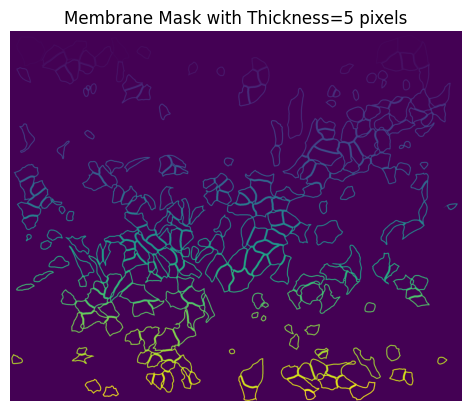

In [13]:
# Run this cell to test on a file in your dataset
row = all_paths_df.iloc[index]
print(f"Testing on file: {row.file} from cell line: {row.cell_line}, tech rep: {row.tech_rep}")
relabeled_nuclear_mask, cleaned_cytoplasmic_mask, cytoplasm_only_mask, membrane_only_mask = load_and_create_masks_for_row(row, membrane_thickness=membrane_thickness)
# Open and display with imshow
fig, ax = plt.subplots()
ax.imshow(membrane_only_mask, cmap='viridis')
ax.set_title(f'Membrane Mask with Thickness={membrane_thickness} pixels')
ax.axis('off')
plt.show()

## Batch process all files

In [14]:
# Parameters for batch processing. Adjust as needed.
channel_index = 3  # Adjust based on actual channel index for intensity image;
# To find out, you can open the .nd2 file with AICSImage in napari and check the channel names/indices
# The channel that appears as the lowest in napari viewer is usually index 0, next is index 1, and so on.
# For this example, we assume channel index 3 is the desired intensity image channel.
# For this batch, channels are: {0: TRANS; 1: DAPI; 2: FITC; 3: TRITC;}
start_index = 0 # Change this to the desired start index; If processing all files, set to 0
end_index = len(all_paths_df)  # Process all files from start_index to the end

In [15]:
# Batch processing loop. Do not modify below this line unless necessary.
all_regionprops = []
# Get channel names from the first file to determine how many channels are in the dataset (assuming all files have the same channels)
try:
    aics_image = AICSImage(all_paths_df.iloc[0].raw_data_path)
    channel_names = aics_image.channel_names
    n_channels = len(channel_names)
    print(f"Detected {n_channels} channels in the dataset: {channel_names}")
except Exception as e:
    print(f"Error loading first file to determine channel information. Defaulting to 1 channel. Error: {str(e)}")
    n_channels = 1
# Write log .txt file to SAVE_DIR
log_file_path = os.path.join(SAVE_DIR, "processing_log.txt")
with open(log_file_path, 'w') as log_file:
    log_file.write(f"Processing started on {today}\n")
    log_file.write(f"Membrane thickness set to: {membrane_thickness} pixels\n")
    for channel in range(n_channels):
        log_file.write(f"Channel {channel} name: {channel_names[channel]}\n")
    log_file.write(f"Total files to process: {len(all_paths_df)}\n\n")
for row in tqdm(all_paths_df.iloc[start_index:end_index].itertuples(), total=len(all_paths_df.iloc[start_index:end_index]), desc="Processing files", unit="file"):
    # Define directory to save outputs using the same structure as raw data but in SAVE_DIR folder
    relative_path = os.path.relpath(row.raw_data_path, ROOT_DIR)
    output_dir = os.path.join(SAVE_DIR, os.path.dirname(os.path.dirname(relative_path)))
    os.makedirs(output_dir, exist_ok=True)

    # Load masks
    try:
        relabeled_nuclear_mask, cleaned_cytoplasmic_mask, cytoplasm_only_mask, membrane_only_mask = load_and_create_masks_for_row(row, 
                                                                                                                              membrane_thickness=membrane_thickness)
    except Exception as e:
        print(f"Error processing masks for file: {row.file}. Skipping.")
        with open(log_file_path, 'a') as log_file:
            log_file.write(f"Error processing masks for cell line {row.cell_line}, tech rep {row.tech_rep} file: {row.file}. Error: {str(e)}\n")
        continue
                              
    # Load intensity image from raw data
    try:
        aics_image = AICSImage(row.raw_data_path)
        intensity_image = aics_image.get_image_data("YXC")  # Running regionprops on all channels (YXC) to keep the same shape as masks; intensity values will be taken from the specified channel index when calculating region properties
        # Save original image as ome-tiff
        aics_image.save(os.path.join(output_dir, f"{os.path.splitext(row.file)[0]}_original_image.ome.tiff"))
        # Save channel data and masks as ome-tiff with physical pixel sizes from raw data
        pixel_sizes = aics_image.physical_pixel_sizes
    except Exception as e:
        print(f"Error loading raw data for file: {row.file}. Skipping.")
        with open(log_file_path, 'a') as log_file:
            log_file.write(f"Error loading raw data for cell line {row.cell_line}, tech rep {row.tech_rep} file: {row.file}. Error: {str(e)}\n")
        continue

    # Save masks as OME-TIFF
    try:
        OmeTiffWriter.save(data=relabeled_nuclear_mask.astype(np.uint16),
                        uri=os.path.join(output_dir, f"{os.path.splitext(row.file)[0]}_nuclei_mask.ome.tiff"),
                        dimension_order="YX",
                        physical_pixel_sizes=pixel_sizes)
        OmeTiffWriter.save(data=cytoplasm_only_mask.astype(np.uint16),
                        uri=os.path.join(output_dir, f"{os.path.splitext(row.file)[0]}_cytoplasm_mask.ome.tiff"),
                        dimension_order="YX",
                        physical_pixel_sizes=pixel_sizes)
        OmeTiffWriter.save(data=membrane_only_mask.astype(np.uint16),
                        uri=os.path.join(output_dir, f"{os.path.splitext(row.file)[0]}_membrane_mask.ome.tiff"),
                        dimension_order="YX",
                        physical_pixel_sizes=pixel_sizes)
    except Exception as e:
        print(f"Error saving masks for file: {row.file}. Skipping.")
        with open(log_file_path, 'a') as log_file:
            log_file.write(f"Error saving masks for cell line {row.cell_line}, tech rep {row.tech_rep} file: {row.file}. Error: {str(e)}\n")
        continue

    # Get region properties with intensity ratios
    try:
        regionprops_df = get_regionprops_with_ratio(relabeled_nuclear_mask, cytoplasm_only_mask, 
                                                    membrane_only_mask, intensity_image, n_channels=n_channels)
        # Annotate with cell line, tech rep, and file info
        regionprops_df['file'] = row.file
        regionprops_df['cell_line'] = row.cell_line
        regionprops_df['tech_rep'] = row.tech_rep
        all_regionprops.append(regionprops_df)
    except Exception as e:
        print(f"Error calculating region properties for file: {row.file}. Skipping.")
        # Print error to console and write to log file
        print(f"Error: {str(e)}")
        with open(log_file_path, 'a') as log_file:
            log_file.write(f"Error calculating region properties for cell line {row.cell_line}, tech rep {row.tech_rep} file: {row.file}. Error: {str(e)}\n")
        continue

# Concatenate all region properties into a single DataFrame
all_regionprops_df = pd.concat(all_regionprops, ignore_index=False)

# Save all region properties to a single CSV
all_regionprops_df.to_csv(os.path.join(SAVE_DIR, "Results.csv"))
with open(log_file_path,'a') as log_file:
    log_file.write(f"\nProcessing completed. Results saved to {os.path.join(SAVE_DIR, 'Results.csv')}\n")
    log_file.write(f"Total cells analyzed: {len(all_regionprops_df)}\n")


c:\Users\s03434mv\AppData\Local\anaconda3\envs\dashUND_track\lib\site-packages\dask\tokenize.py:244: UserWarning: ND2File file not closed before garbage collection. Please use `with ND2File(...):` context or call `.close()`.
  mod.loads(out, buffers=buffers)


Detected 4 channels in the dataset: ['TRANS', 'DAPI', 'FITC', 'TRITC']


Processing files:   0%|          | 0/47 [00:00<?, ?file/s]c:\Users\s03434mv\AppData\Local\anaconda3\envs\dashUND_track\lib\site-packages\dask\tokenize.py:244: UserWarning: ND2File file not closed before garbage collection. Please use `with ND2File(...):` context or call `.close()`.
  mod.loads(out, buffers=buffers)
Processing files:   2%|▏         | 1/47 [00:15<11:42, 15.26s/file]c:\Users\s03434mv\AppData\Local\anaconda3\envs\dashUND_track\lib\site-packages\dask\tokenize.py:244: UserWarning: ND2File file not closed before garbage collection. Please use `with ND2File(...):` context or call `.close()`.
  mod.loads(out, buffers=buffers)
Processing files:   4%|▍         | 2/47 [00:28<10:21, 13.81s/file]c:\Users\s03434mv\AppData\Local\anaconda3\envs\dashUND_track\lib\site-packages\dask\tokenize.py:244: UserWarning: ND2File file not closed before garbage collection. Please use `with ND2File(...):` context or call `.close()`.
  mod.loads(out, buffers=buffers)
Processing files:   6%|▋         